# LAB8
### Dewang Choudhary    
### BL.EN.U4AIE23145

Sample rate: 22050 Hz
Frame length: 551 samples
DFT energy in first 20 coefficients: 0.0238
DCT energy in first 20 coefficients: 0.0026


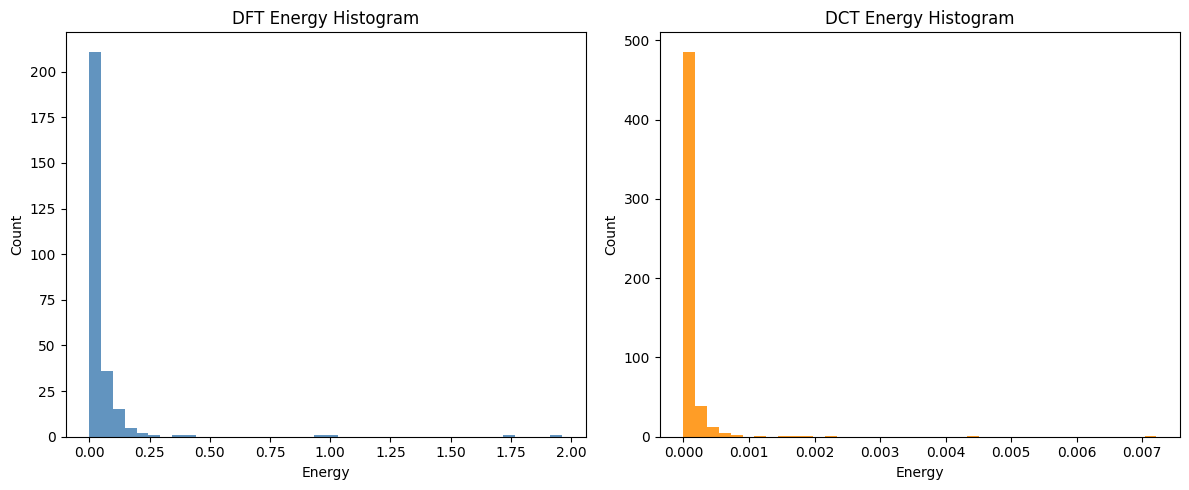

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import rfft
from scipy.fftpack import dct
from scipy.signal import get_window
from pathlib import Path


wav_path = Path.cwd().parent / "LJ001-0003.wav"
sr, signal = wavfile.read(wav_path)
if signal.ndim > 1:
    signal = signal.mean(axis=1)
signal = signal.astype(np.float64)
max_val = np.max(np.abs(signal))
if max_val > 0:
    signal = signal / max_val

frame_len = int(0.025 * sr)
frame = signal[:frame_len]
window = get_window("hamming", frame_len, fftbins=True)
windowed = frame * window

dft_coeff = np.abs(rfft(windowed))
dct_coeff = np.abs(dct(windowed, type=2, norm="ortho"))

dft_energy = dft_coeff ** 2
dct_energy = dct_coeff ** 2

k = 20
k_dft = min(k, len(dft_energy))
k_dct = min(k, len(dct_energy))
dft_ratio = np.sum(dft_energy[:k_dft]) / np.sum(dft_energy)
dct_ratio = np.sum(dct_energy[:k_dct]) / np.sum(dct_energy)

print(f"Sample rate: {sr} Hz")
print(f"Frame length: {frame_len} samples")
print(f"DFT energy in first {k_dft} coefficients: {dft_ratio:.4f}")
print(f"DCT energy in first {k_dct} coefficients: {dct_ratio:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(dft_energy, bins=40, color="steelblue", alpha=0.85)
plt.title("DFT Energy Histogram")
plt.xlabel("Energy")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(dct_energy, bins=40, color="darkorange", alpha=0.85)
plt.title("DCT Energy Histogram")
plt.xlabel("Energy")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

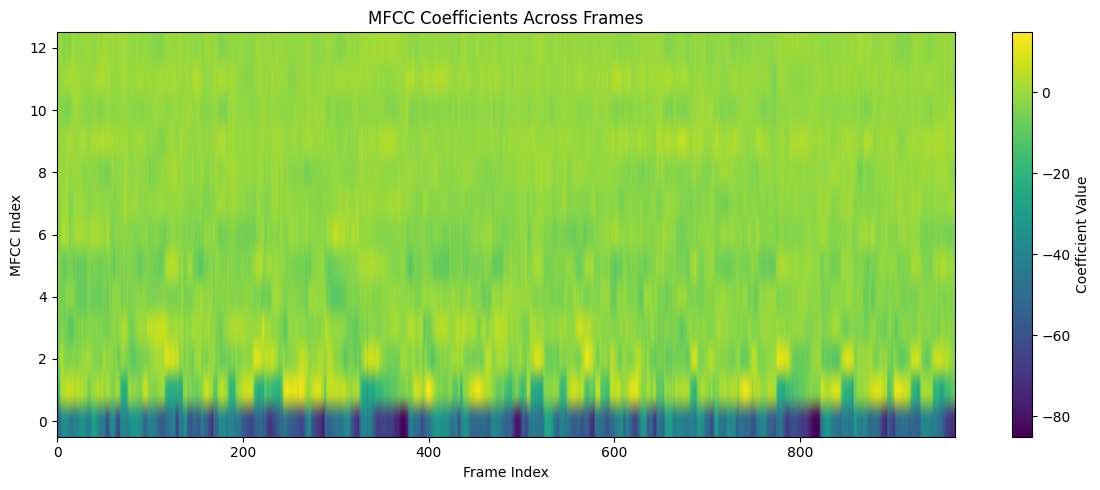

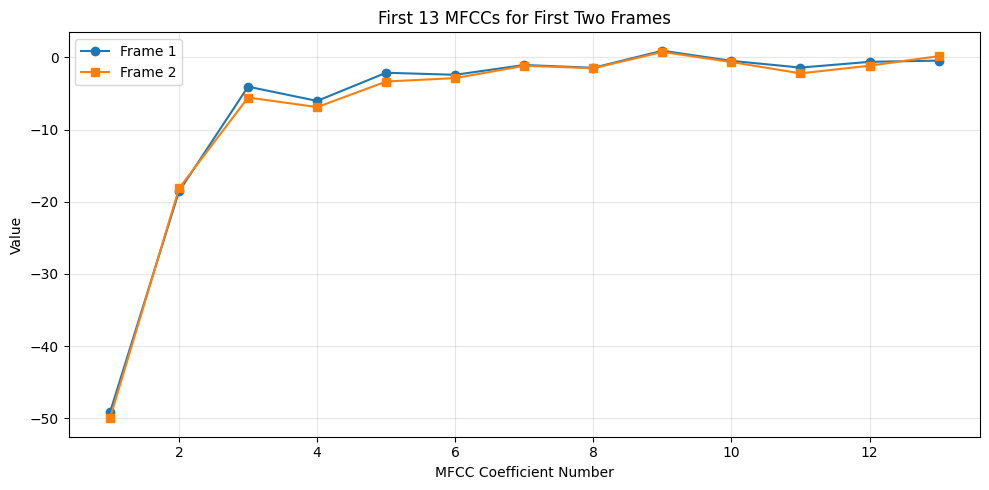

MFCC shape: (968, 13)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct
from scipy.signal import get_window
from pathlib import Path

wav_path = Path.cwd().parent / "LJ001-0003.wav"
sr, signal = wavfile.read(wav_path)
if signal.ndim > 1:
    signal = signal.mean(axis=1)
signal = signal.astype(np.float64)
max_val = np.max(np.abs(signal))
if max_val > 0:
    signal = signal / max_val

pre_emphasis = 0.97
emphasized = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])

frame_size = 0.025
frame_stride = 0.01
frame_length = int(round(frame_size * sr))
frame_step = int(round(frame_stride * sr))
signal_length = len(emphasized)
num_frames = int(np.ceil(np.abs(signal_length - frame_length) / frame_step)) + 1

pad_signal_length = num_frames * frame_step + frame_length
z = np.zeros((pad_signal_length - signal_length,))
pad_signal = np.append(emphasized, z)

indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
frames = pad_signal[indices.astype(np.int32, copy=False)]
frames = frames * get_window("hamming", frame_length, fftbins=True)

nfft = 512
mag_frames = np.absolute(np.fft.rfft(frames, nfft))
pow_frames = (1.0 / nfft) * (mag_frames ** 2)

nfilt = 26
low_mel = 0
high_mel = 2595 * np.log10(1 + (sr / 2) / 700)
mel_points = np.linspace(low_mel, high_mel, nfilt + 2)
hz_points = 700 * (10 ** (mel_points / 2595) - 1)
bin_points = np.floor((nfft + 1) * hz_points / sr).astype(int)

fbank = np.zeros((nfilt, int(np.floor(nfft / 2 + 1))))
for m in range(1, nfilt + 1):
    f_m_minus = bin_points[m - 1]
    f_m = bin_points[m]
    f_m_plus = bin_points[m + 1]
    if f_m == f_m_minus:
        f_m += 1
    if f_m_plus == f_m:
        f_m_plus += 1
    for k in range(f_m_minus, f_m):
        fbank[m - 1, k] = (k - f_m_minus) / (f_m - f_m_minus)
    for k in range(f_m, f_m_plus):
        fbank[m - 1, k] = (f_m_plus - k) / (f_m_plus - f_m)

filter_banks = np.dot(pow_frames, fbank.T)
filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
log_filter_banks = np.log(filter_banks)

num_ceps = 13
mfcc = dct(log_filter_banks, type=2, axis=1, norm='ortho')[:, :num_ceps]

plt.figure(figsize=(12, 5))
plt.imshow(mfcc.T, aspect='auto', origin='lower', cmap='viridis')
plt.title('MFCC Coefficients Across Frames')
plt.xlabel('Frame Index')
plt.ylabel('MFCC Index')
plt.colorbar(label='Coefficient Value')
plt.tight_layout()
plt.show()

first_two = mfcc[:2, :]
x = np.arange(1, num_ceps + 1)

plt.figure(figsize=(10, 5))
plt.plot(x, first_two[0], marker='o', label='Frame 1')
if first_two.shape[0] > 1:
    plt.plot(x, first_two[1], marker='s', label='Frame 2')
plt.title('First 13 MFCCs for First Two Frames')
plt.xlabel('MFCC Coefficient Number')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MFCC shape: {mfcc.shape}")